
=============== ID3 (chefboost) ===============
26-10-08 00:04:41 - ID3 tree is going to be built...
26-10-08 00:04:48 - -------------------------
26-10-08 00:04:48 - finished in 7.128905773162842 seconds
26-10-08 00:04:48 - -------------------------
26-10-08 00:04:48 - Evaluate train set
26-10-08 00:04:48 - -------------------------
26-10-08 00:04:48 - Accuracy: 100.0% on 30 instances
26-10-08 00:04:48 - Labels: ['Alto' 'Moderado' 'Baixo']
26-10-08 00:04:48 - Confusion matrix: [[11, 0, 0], [0, 9, 0], [0, 0, 10]]
26-10-08 00:04:48 - Decision Alto
26-10-08 00:04:48 - Accuracy: 100.0
26-10-08 00:04:48 - Precision: 100.0%, Recall: 100.0%, F1: 100.0%
26-10-08 00:04:48 - Decision Moderado
26-10-08 00:04:48 - Accuracy: 100.0
26-10-08 00:04:48 - Precision: 100.0%, Recall: 100.0%, F1: 100.0%
26-10-08 00:04:48 - Decision Baixo
26-10-08 00:04:48 - Accuracy: 100.0
26-10-08 00:04:48 - Precision: 100.0%, Recall: 100.0%, F1: 100.0%

--- Regras ID3 ---
R1: SE Renda = "Acima de $35k" E História de Cr

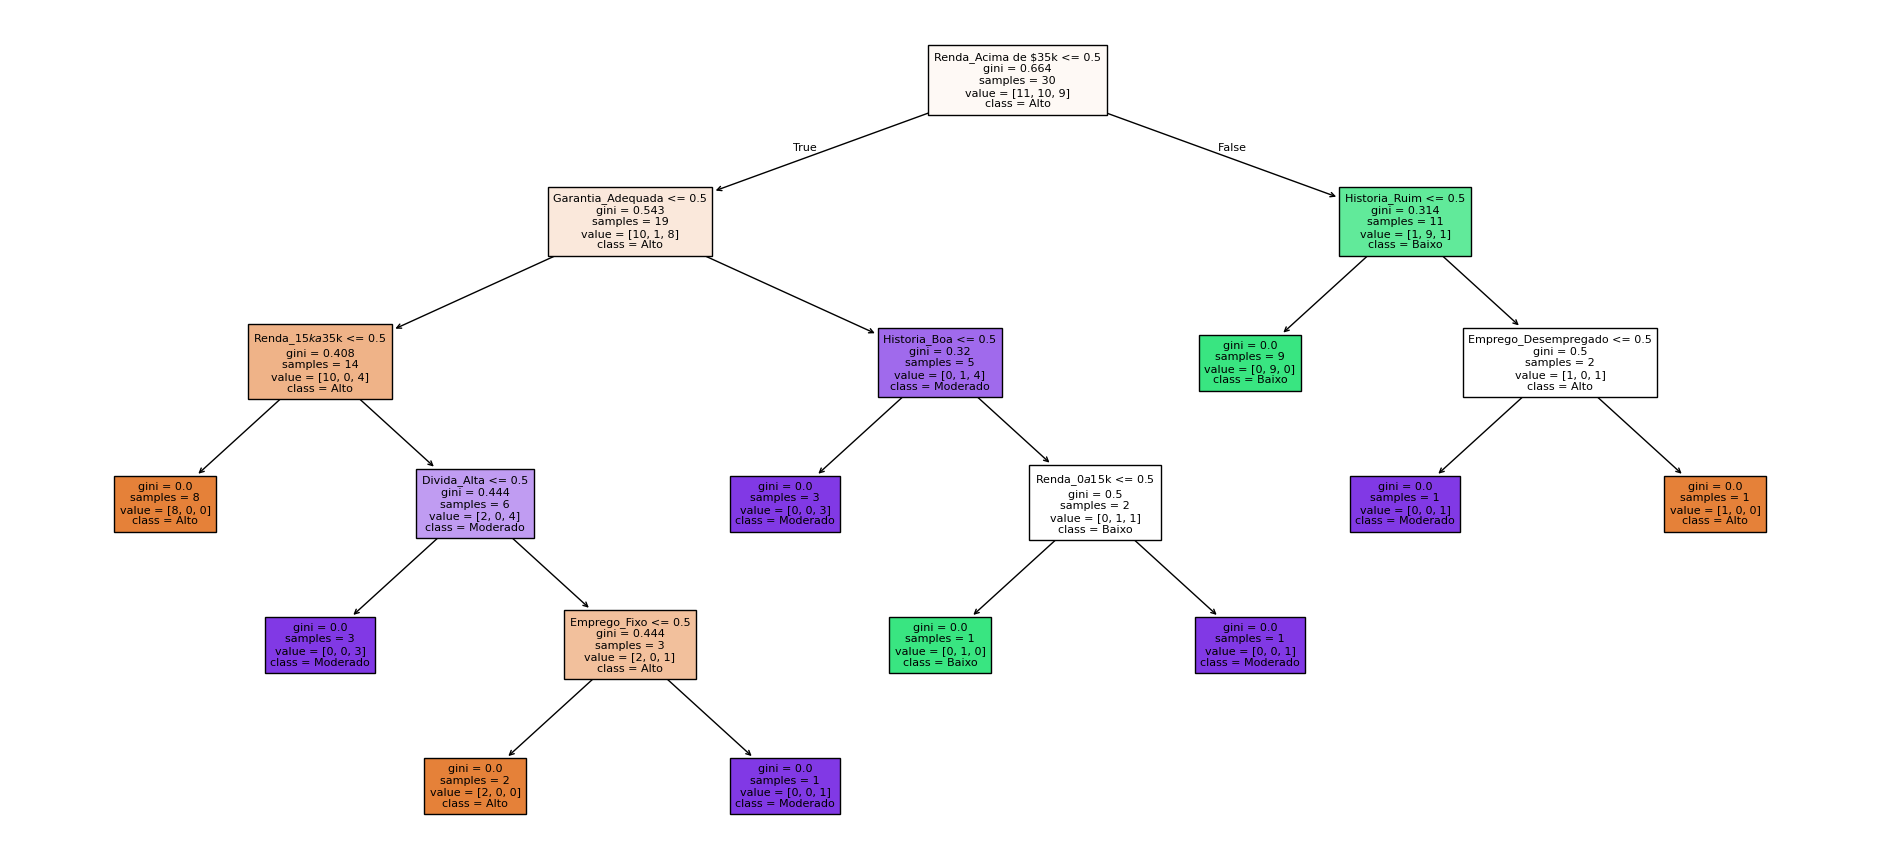

In [10]:
import re, shutil
import pandas as pd
import matplotlib.pyplot as plt
from chefboost import Chefboost as chef
from sklearn.tree import DecisionTreeClassifier, plot_tree

FEATURES = ["Historia", "Divida", "Garantia", "Renda", "Emprego", "Idade"]
NOMES = {"Historia": "História de Crédito", "Divida": "Dívida"}

df = pd.read_csv("arquivo.csv")[FEATURES + ["Risco"]]
df_cb = df.rename(columns={"Risco": "Decision"})

def nome(f):
    return NOMES.get(f, f)

# conversão de regras geradas em se...então
def regras_chefboost(caminho):
    regras, pilha = [], []
    for linha in open(caminho, encoding="utf-8"):
        codigo = linha.split("#")[0].rstrip()
        t = codigo.strip()
        if not t:
            continue
        ind = len(codigo) - len(t)

        if t.startswith(("if ", "elif ", "else")):
            while pilha and pilha[-1][0] >= ind:
                pilha.pop()
            m = re.findall(r"obj\[(\d+)\]\s*==\s*['\"]([^'\"]*)['\"]", t)
            cond = " E ".join(f'{nome(FEATURES[int(i)])} = "{v}"' for i, v in m) if m else None
            pilha.append((ind, cond))

        elif t.startswith("return"):
            while pilha and pilha[-1][0] >= ind:
                pilha.pop()
            classe = re.findall(r"return\s+['\"]([^'\"]*)['\"]", t)[0]
            conds = [c for _, c in pilha]


            if None in conds:
                continue

            regras.append((conds, classe))
    return regras

# id3 e c4.5
resumo = {}
for alg in ["ID3", "C4.5"]:
    print(f"\n{'=' * 15} {alg} (chefboost) {'=' * 15}")
    config = {"algorithm": alg}

    try:
        modelo = chef.fit(df_cb.copy(), config=config, target_label="Decision")
    except TypeError:
        modelo = chef.fit(df_cb.copy(), config=config)

    arq = f"rules_{alg.replace('.', '')}.py"
    shutil.copy("outputs/rules/rules.py", arq)

    print(f"\n--- Regras {alg} ---")
    rs = regras_chefboost(arq)
    for i, (conds, classe) in enumerate(rs, 1):
        print(f"R{i}: SE " + " E ".join(conds) + f" ENTÃO Risco = {classe}")

    acertos = sum(chef.predict(modelo, list(r[FEATURES])) == r["Risco"] for _, r in df.iterrows())
    resumo[alg] = (len(rs), acertos / len(df))
    print(f"Regras: {len(rs)} | Acurácia no treino: {acertos / len(df):.2%}")


# CART
X = pd.get_dummies(df[FEATURES]).astype(int)
y = df["Risco"]
cart = DecisionTreeClassifier(criterion="gini", random_state=42).fit(X, y)
nomes_cols = list(X.columns)

def regras_sklearn(clf, nomes_cols):
    t = clf.tree_
    def rec(no, cond):
        if t.children_left[no] == -1:
            yield cond, clf.classes_[t.value[no][0].argmax()]
            return

        attr_bruto, val = nomes_cols[t.feature[no]].split("_", 1)
        attr_formatado = nome(attr_bruto)

        yield from rec(t.children_left[no],  cond + [f'{attr_formatado} ≠ "{val}"'])
        yield from rec(t.children_right[no], cond + [f'{attr_formatado} = "{val}"'])

    return list(rec(0, []))

print(f"\n{'=' * 15} CART (scikit-learn) {'=' * 15}")
rs_cart = regras_sklearn(cart, nomes_cols)
for i, (conds, classe) in enumerate(rs_cart, 1):
    print(f"R{i}: SE " + " E ".join(conds) + f" ENTÃO Risco = {classe}")

acuracia_cart = cart.score(X, y)
print(f"Regras: {len(rs_cart)} | Folhas: {cart.get_n_leaves()} | Profundidade: {cart.get_depth()} | "
      f"Acurácia no treino: {acuracia_cart:.2%}")

resumo["CART"] = (len(rs_cart), acuracia_cart)

# desenho da árvore CART
plt.figure(figsize=(24, 11))
plot_tree(cart, feature_names=nomes_cols, class_names=list(cart.classes_), filled=True, fontsize=8)
plt.savefig("cart.png", dpi=150, bbox_inches="tight")


print("\n")
print(" "*13 + "RESUMO FINAL")
print("="*40)
for alg, (n, acc) in resumo.items():
    print(f"{alg:<5} : {n} regras | Acurácia no treino: {acc:.2%}")